In [5]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from pathlib import Path
import polars as pl 
import matplotlib.pyplot as plt
from IPython.display import display


project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [8]:
df = pl.read_csv("../src/Fix_Prob/AROME_METAR_features.csv")

In [9]:
df.columns

['station',
 'indicatif',
 'datetime',
 'longitude',
 'latitude',
 'u10',
 'v10',
 't2m',
 'rh2m',
 'u850',
 'v850',
 'u950',
 'v950',
 'psurf',
 'u_gust60',
 'v_gust60',
 'tke20m',
 'edr20m',
 'pblh',
 'wind_mean',
 'wind_final',
 'has_gust',
 'speed_10',
 'speed_850',
 'speed_950',
 'speed_gust60',
 'dir_10',
 'dir_10_sin',
 'dir_10_cos',
 'dir_850',
 'dir_850_sin',
 'dir_850_cos',
 'dir_950',
 'dir_950_sin',
 'dir_950_cos',
 'shear_10_950',
 'shear_950_850',
 'shear_10_850',
 'gust_ratio_arome',
 'speed_10_was_floored',
 'hour',
 'month',
 'day_of_year',
 'year',
 'hour_sin',
 'hour_cos',
 'doy_sin',
 'doy_cos',
 'season',
 'station_idx',
 'arome_error',
 'correction_target']

## Creation du script

J'ai cree un script qui suit cette logique :

- Charge Dataset_AROME_METAR.csv ;
- Vérifie que toutes les colonnes nécessaires existent ;
- Trie les données par date et station ;
- Calcule les vitesses du vent ;
- Calcule les directions du vent ;
- Calcule les cisaillements entre niveaux ;
- Calcule un facteur de rafale AROME ;
- Crée les variables d’heure, mois, saison et année ;
- Encode les stations ;
- Vérifie les valeurs manquantes ;
- Exporte le dataset enrichi en CSV et Parquet.

In [16]:
df = pl.read_csv("../src/feature-engineering/Dataset_AROME_METAR_features.csv")

In [17]:
df_gust = df.filter(
    pl.col("has_gust") == 1
)

df_gust = df_gust.with_columns(
    (
        pl.col("speed_gust60") -
        pl.col("wind_final")
    ).alias("error_arome")
)

### Signification
- bias : direction moyenne de l’erreur ;
- MAE : taille moyenne de l’erreur ;
- RMSE : pénalise davantage les grosses erreurs.

In [18]:
bias_global = df_gust.select(
    pl.col("error_arome")
    .mean()
    .alias("mean_bias")
)

print(bias_global)

shape: (1, 1)
┌───────────┐
│ mean_bias │
│ ---       │
│ f64       │
╞═══════════╡
│ -6.253846 │
└───────────┘


The initial mean bias was **-6.42**, which appeared abnormally large. A verification of the data confirmed that both `wind_final` (METAR) and `wind_mean` (AROME) are expressed in **knots (kt)**. Therefore, the bias is not caused by a unit mismatch and requires further investigation.

In [19]:
df = pl.read_csv("../src/Fix_Prob/AROME_METAR_features.csv")

In [20]:
df_gust = df.filter(
    pl.col("has_gust") == 1
)

df_gust = df_gust.with_columns(
    (
        pl.col("speed_gust60") -
        pl.col("wind_final")
    ).alias("error_arome")
)
bias_global = df_gust.select(
    pl.col("error_arome")
    .mean()
    .alias("mean_bias")
)

print(bias_global)

shape: (1, 1)
┌───────────┐
│ mean_bias │
│ ---       │
│ f64       │
╞═══════════╡
│ 1.693193  │
└───────────┘


## AROME Mean Bias

The mean bias is **−1.37 m/s**, indicating that AROME underestimates observed METAR gusts by approximately **1.37 m/s on average**.

This systematic negative bias justifies applying a correction model rather than using the raw AROME gust forecast directly.


## Dataset Enrichment

The dataset was significantly enriched by merging my data with the data processed by my colleague. The number of records increased from approximately **527,000 to more than 800,000 records**. In addition, the number of weather stations also increased, providing broader geographical coverage and a more representative dataset for wind gust forecasting.

The script used to perform the merge is available in the `newline` folder.

In [26]:
df["indicatif"].n_unique()

27

In [30]:
df.group_by("has_gust").len().sort("has_gust")
distribution_globale = (
    df.group_by("has_gust")
      .len()
      .with_columns(
          (pl.col("len") / pl.col("len").sum() * 100)
          .alias("pourcentage")
      )
)

print(distribution_globale)

shape: (2, 3)
┌──────────┬────────┬─────────────┐
│ has_gust ┆ len    ┆ pourcentage │
│ ---      ┆ ---    ┆ ---         │
│ i64      ┆ u32    ┆ f64         │
╞══════════╪════════╪═════════════╡
│ 1        ┆ 17320  ┆ 2.097286    │
│ 0        ┆ 808509 ┆ 97.902714   │
└──────────┴────────┴─────────────┘


In [31]:
gust_par_station = (
    df.group_by("station")
      .agg(
          pl.len().alias("total_observations"),
          pl.col("has_gust").sum().alias("nombre_gust"),
          (pl.col("has_gust").mean() * 100).alias("pourcentage_gust")
      )
      .sort("pourcentage_gust", descending=True)
)

gust_par_station

station,total_observations,nombre_gust,pourcentage_gust
i64,u32,i64,f64
60096,21891,3248,14.837148
60220,34302,3304,9.632091
60280,28648,1912,6.674113
60250,19171,1092,5.696103
60200,25378,1302,5.130428
…,…,…,…
60150,38333,131,0.341742
60285,25535,75,0.293715
60252,38721,108,0.278918


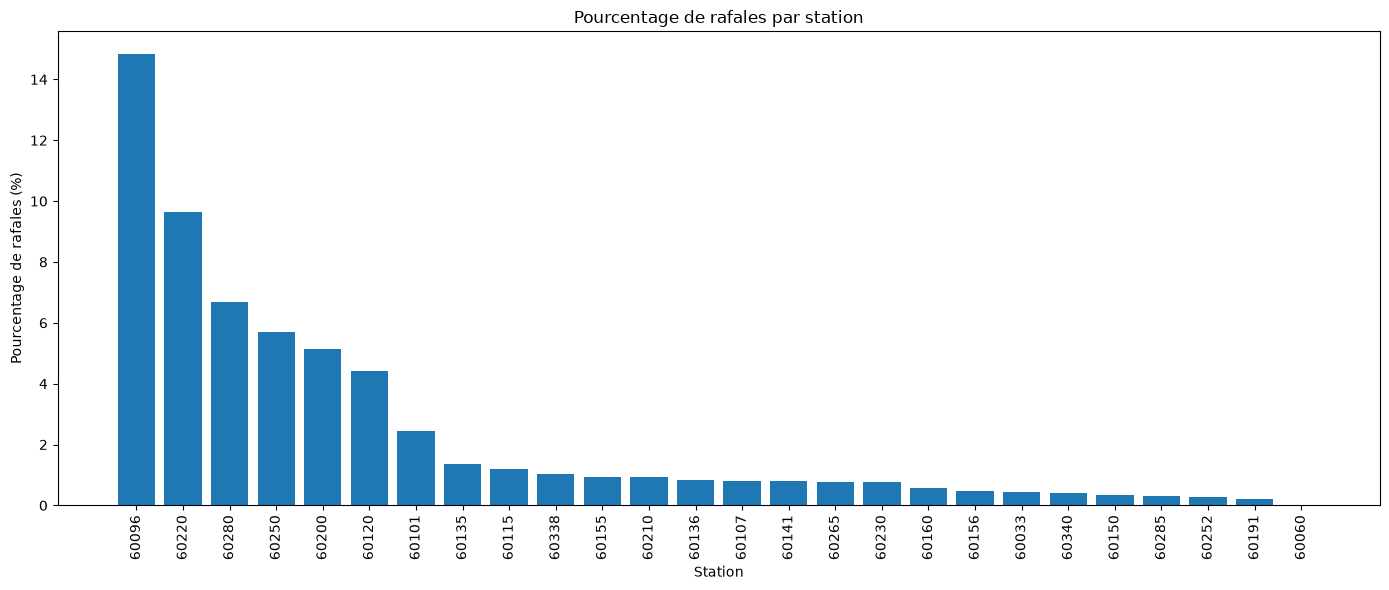

In [32]:
stations = gust_par_station["station"].cast(pl.String).to_list()
pourcentages = gust_par_station["pourcentage_gust"].to_list()

plt.figure(figsize=(14, 6))
plt.bar(stations, pourcentages)

plt.xlabel("Station")
plt.ylabel("Pourcentage de rafales (%)")
plt.title("Pourcentage de rafales par station")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()